# Transformer

This notebook is set up to run **four experiments** for your transformer-based segmentation work and
log every run into an Excel workbook automatically:

1. **baseline**
2. **finetune**
3. **augmentation**
4. **best checkpoint**

It is written for the EWS wheat segmentation project and is intended to fit the repo style where
people show an experiment progression rather than only one final notebook.

In [15]:

!pip -q install -U transformers accelerate openpyxl


In [16]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import time
import copy
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import openpyxl

from torchvision.transforms import ColorJitter
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import InterpolationMode

from transformers import (
    AutoImageProcessor,
    SegformerForSemanticSegmentation,
    UperNetForSemanticSegmentation,
    DPTForSemanticSegmentation,
    Mask2FormerForUniversalSegmentation,
)


In [18]:
# DATA_ROOT = "/content/drive/MyDrive/COMP9517/ass1/EWS-Dataset"
# New root for video demo
DATA_ROOT = "/content/drive/MyDrive/COMP9517 assignment/EWS-Dataset"


PROJECT_ROOT = "/content/drive/MyDrive/COMP9517/ass1"

SAVE_DIR = os.path.join(PROJECT_ROOT, "dl", "em", "checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)

RESULTS_XLSX_PATH = os.path.join(PROJECT_ROOT, "training_results_history.xlsx")

RESULTS_SHEET_NAME = "em_transformer_runs"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2
SEED = 42

ID2LABEL = {0: "soil", 1: "wheat"}
LABEL2ID = {"soil": 0, "wheat": 1}
NUM_LABELS = 2

CHECKPOINTS = {
    "segformer": "nvidia/segformer-b0-finetuned-ade-512-512",
    "swin": "openmmlab/upernet-swin-tiny",
    "vit": "Intel/dpt-large-ade",
    "mask2former": "facebook/mask2former-swin-tiny-ade-semantic",
}

EXPERIMENTS = [
    {
        "run_name": "em_segformer_baseline",
        "stage": "baseline",
        "model_type": "segformer",
        "image_size": 352,
        "batch_size": 4,
        "epochs": 10,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "train_aug": False,
        "notes": "Baseline SegFormer run"
    },
    {
        "run_name": "em_segformer_finetune",
        "stage": "finetune",
        "model_type": "segformer",
        "image_size": 384,
        "batch_size": 4,
        "epochs": 20,
        "lr": 5e-5,
        "weight_decay": 1e-4,
        "train_aug": False,
        "notes": "Longer training and smaller learning rate"
    },
    {
        "run_name": "em_segformer_augmentation",
        "stage": "augmentation",
        "model_type": "segformer",
        "image_size": 384,
        "batch_size": 4,
        "epochs": 20,
        "lr": 5e-5,
        "weight_decay": 1e-4,
        "train_aug": True,
        "notes": "SegFormer with data augmentation"
    },
    {
        "run_name": "em_segformer_best_checkpoint",
        "stage": "best_checkpoint",
        "model_type": "segformer",
        "image_size": 384,
        "batch_size": 4,
        "epochs": 30,
        "lr": 3e-5,
        "weight_decay": 1e-4,
        "train_aug": True,
        "notes": "Final best-checkpoint experiment"
    },
]

print("Using device:", DEVICE)
print("Data root:", DATA_ROOT)
print("Project root:", PROJECT_ROOT)
print("Results workbook:", RESULTS_XLSX_PATH)


Using device: cuda
Data root: /content/drive/MyDrive/COMP9517 assignment/EWS-Dataset
Project root: /content/drive/MyDrive/COMP9517/ass1
Results workbook: /content/drive/MyDrive/COMP9517/ass1/training_results_history.xlsx


In [19]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def find_existing_dir(root: Path, candidates):
    for name in candidates:
        p = root / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any of {candidates} inside {root}")

def find_split_dir(data_root: Path, split_name: str):
    split_options = {
        "train": ["train", "training"],
        "validation": ["validation", "valid", "val"],
        "test": ["test", "testing"],
    }
    return find_existing_dir(data_root, split_options[split_name])

def find_subdir(root: Path, candidates):
    for name in candidates:
        p = root / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any of {candidates} inside {root}")

def canonical_stem(path: Path):
    s = path.stem.lower()
    for suffix in ["_mask", "_label", "_labels", "_annotation", "_ann"]:
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s.rstrip("_-")

def load_binary_mask(mask_path: str):
    mask = Image.open(mask_path).convert("L")
    mask = np.array(mask)
    mask = (mask > 127).astype(np.uint8)
    return mask


In [20]:

class JointSegmentationAugmentation:
    def __init__(self):
        self.color_jitter = ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.08,
            hue=0.02
        )

    def __call__(self, image, mask_np):
        mask = Image.fromarray(mask_np.astype(np.uint8))

        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if random.random() < 0.2:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        if random.random() < 0.6:
            angle = random.choice([-15, -10, -5, 5, 10, 15])
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        if random.random() < 0.6:
            image = self.color_jitter(image)

        mask_np = np.array(mask).astype(np.uint8)
        mask_np = (mask_np > 0).astype(np.uint8)
        return image, mask_np


In [21]:

class EWSSegmentationDataset(Dataset):
    def __init__(self, split_dir, processor, model_type, image_size=352, augment=False):
        self.split_dir = Path(split_dir)
        self.processor = processor
        self.model_type = model_type
        self.image_size = image_size
        self.augment = augment
        self.augmenter = JointSegmentationAugmentation() if augment else None

        image_candidates = ["images", "image", "imgs", "img", "rgb", "."]
        mask_candidates = ["masks", "mask", "labels", "label", "annotations", "annotation", "."]

        image_dir = find_subdir(self.split_dir, image_candidates)
        mask_dir = find_subdir(self.split_dir, mask_candidates)

        image_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            image_files.extend(sorted(image_dir.glob(ext)))

        mask_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            mask_files.extend(sorted(mask_dir.glob(ext)))

        if not image_files or not mask_files:
            raise RuntimeError(f"No images or masks found in {self.split_dir}")

        mask_map = {canonical_stem(p): p for p in mask_files}
        self.samples = []

        for img_path in image_files:
            key = canonical_stem(img_path)
            if key in mask_map:
                self.samples.append((str(img_path), str(mask_map[key])))

        if len(self.samples) == 0:
            if len(image_files) != len(mask_files):
                raise RuntimeError(
                    "Could not pair images and masks by filename, and counts do not match."
                )
            self.samples = [(str(i), str(m)) for i, m in zip(sorted(image_files), sorted(mask_files))]

        print(f"{self.split_dir.name}: {len(self.samples)} image/mask pairs found")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]

        image = Image.open(image_path).convert("RGB")
        orig_mask_np = load_binary_mask(mask_path)

        if self.augmenter is not None:
            image, orig_mask_np = self.augmenter(image, orig_mask_np)

        orig_h, orig_w = orig_mask_np.shape
        seg_map = Image.fromarray(orig_mask_np.astype(np.uint8))

        encoded = self.processor(
            images=image,
            segmentation_maps=seg_map,
            return_tensors="pt",
            do_resize=True,
            size={"height": self.image_size, "width": self.image_size},
            do_reduce_labels=False,
        )

        item = {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "orig_mask": torch.from_numpy(orig_mask_np).long(),
            "orig_size": (orig_h, orig_w),
            "image_id": Path(image_path).stem,
        }

        if self.model_type == "mask2former":
            item["pixel_mask"] = encoded["pixel_mask"].squeeze(0)
            item["mask_labels"] = encoded["mask_labels"][0]
            item["class_labels"] = encoded["class_labels"][0]
        else:
            labels = encoded["labels"]
            if labels.ndim == 3:
                labels = labels.squeeze(0)
            item["labels"] = labels.long()

        return item


In [22]:

def make_collate_fn(model_type):
    def collate_fn(batch):
        out = {
            "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
            "orig_masks": [x["orig_mask"] for x in batch],
            "orig_sizes": [x["orig_size"] for x in batch],
            "image_ids": [x["image_id"] for x in batch],
        }

        if model_type == "mask2former":
            out["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
            out["mask_labels"] = [x["mask_labels"] for x in batch]
            out["class_labels"] = [x["class_labels"] for x in batch]
        else:
            out["labels"] = torch.stack([x["labels"] for x in batch])

        return out
    return collate_fn


In [23]:

def build_processor_and_model(model_type):
    ckpt = CHECKPOINTS[model_type]

    processor = AutoImageProcessor.from_pretrained(
        ckpt,
        do_reduce_labels=False,
    )

    common_kwargs = dict(
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    if model_type == "segformer":
        model = SegformerForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "swin":
        model = UperNetForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "vit":
        model = DPTForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "mask2former":
        model = Mask2FormerForUniversalSegmentation.from_pretrained(ckpt, **common_kwargs)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return processor, model


In [24]:

def compute_binary_metrics(tp, fp, fn, tn):
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-8)

    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "iou": float(iou),
        "accuracy": float(accuracy),
    }

def update_confusion_counts(pred_mask, true_mask, counts):
    pred = pred_mask.view(-1)
    true = true_mask.view(-1)

    counts["tp"] += int(((pred == 1) & (true == 1)).sum().item())
    counts["fp"] += int(((pred == 1) & (true == 0)).sum().item())
    counts["fn"] += int(((pred == 0) & (true == 1)).sum().item())
    counts["tn"] += int(((pred == 0) & (true == 0)).sum().item())

def forward_loss(model, batch, model_type):
    if model_type == "mask2former":
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            pixel_mask=batch["pixel_mask"].to(DEVICE),
            mask_labels=[x.to(DEVICE) for x in batch["mask_labels"]],
            class_labels=[x.to(DEVICE) for x in batch["class_labels"]],
        )
    else:
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            labels=batch["labels"].to(DEVICE),
        )
    return outputs

@torch.no_grad()
def predict_batch(model, processor, batch, model_type):
    if model_type == "mask2former":
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            pixel_mask=batch["pixel_mask"].to(DEVICE),
        )
        preds = processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=batch["orig_sizes"],
        )
        preds = [p.cpu().long() for p in preds]
    else:
        outputs = model(pixel_values=batch["pixel_values"].to(DEVICE))
        logits = outputs.logits
        preds = []

        for i, (h, w) in enumerate(batch["orig_sizes"]):
            resized = F.interpolate(
                logits[i].unsqueeze(0),
                size=(h, w),
                mode="bilinear",
                align_corners=False,
            )
            pred = resized.argmax(dim=1).squeeze(0).cpu().long()
            preds.append(pred)

    return preds

def train_one_epoch(model, loader, optimizer, model_type):
    model.train()
    total_loss = 0.0

    for batch in loader:
        optimizer.zero_grad()
        outputs = forward_loss(model, batch, model_type)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

@torch.no_grad()
def evaluate(model, processor, loader, model_type):
    model.eval()
    total_loss = 0.0
    counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}

    for batch in loader:
        outputs = forward_loss(model, batch, model_type)
        total_loss += outputs.loss.item()

        preds = predict_batch(model, processor, batch, model_type)
        for pred, target in zip(preds, batch["orig_masks"]):
            update_confusion_counts(pred, target, counts)

    metrics = compute_binary_metrics(**counts)
    metrics["loss"] = float(total_loss / max(len(loader), 1))
    return metrics


In [25]:

RESULT_COLUMNS = [
    "timestamp",
    "contributor",
    "run_name",
    "stage",
    "model_type",
    "image_size",
    "batch_size",
    "epochs",
    "lr",
    "weight_decay",
    "train_aug",
    "best_epoch",
    "val_loss",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_iou",
    "test_loss",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_iou",
    "train_time_s",
    "test_time_s",
    "checkpoint_path",
    "notes",
]

def ensure_results_workbook(xlsx_path, sheet_name):
    if not os.path.exists(xlsx_path):
        wb = openpyxl.Workbook()
        ws = wb.active
        ws.title = sheet_name
        ws.append(RESULT_COLUMNS)
        wb.save(xlsx_path)
        return

    wb = openpyxl.load_workbook(xlsx_path)
    if sheet_name not in wb.sheetnames:
        ws = wb.create_sheet(sheet_name)
        ws.append(RESULT_COLUMNS)
        wb.save(xlsx_path)

def upsert_result_row(xlsx_path, sheet_name, row_dict):
    ensure_results_workbook(xlsx_path, sheet_name)

    wb = openpyxl.load_workbook(xlsx_path)
    ws = wb[sheet_name]

    headers = [cell.value for cell in ws[1]]
    run_name_col = headers.index("run_name") + 1

    target_row = None
    for row_idx in range(2, ws.max_row + 1):
        if ws.cell(row=row_idx, column=run_name_col).value == row_dict["run_name"]:
            target_row = row_idx
            break

    values = [row_dict.get(col, "") for col in RESULT_COLUMNS]

    if target_row is None:
        ws.append(values)
    else:
        for col_idx, value in enumerate(values, start=1):
            ws.cell(row=target_row, column=col_idx).value = value

    wb.save(xlsx_path)
    print(f"Logged results to {xlsx_path} [{sheet_name}] for {row_dict['run_name']}")


In [26]:

def build_loaders(exp, processor):
    data_root = Path(DATA_ROOT)

    train_set = EWSSegmentationDataset(
        find_split_dir(data_root, "train"),
        processor,
        exp["model_type"],
        image_size=exp["image_size"],
        augment=exp["train_aug"],
    )
    val_set = EWSSegmentationDataset(
        find_split_dir(data_root, "validation"),
        processor,
        exp["model_type"],
        image_size=exp["image_size"],
        augment=False,
    )
    test_set = EWSSegmentationDataset(
        find_split_dir(data_root, "test"),
        processor,
        exp["model_type"],
        image_size=exp["image_size"],
        augment=False,
    )

    collate_fn = make_collate_fn(exp["model_type"])

    train_loader = DataLoader(
        train_set,
        batch_size=exp["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )

    val_loader = DataLoader(
        val_set,
        batch_size=exp["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )

    test_loader = DataLoader(
        test_set,
        batch_size=exp["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )

    return train_loader, val_loader, test_loader, train_set, val_set, test_set


In [27]:

def run_experiment(exp):
    print("=" * 80)
    print(f"Starting: {exp['run_name']}")
    print(exp)
    print("=" * 80)

    set_seed(SEED)

    processor, model = build_processor_and_model(exp["model_type"])
    model.to(DEVICE)

    train_loader, val_loader, test_loader, train_set, val_set, test_set = build_loaders(exp, processor)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=exp["lr"],
        weight_decay=exp["weight_decay"],
    )

    checkpoint_path = os.path.join(SAVE_DIR, f"{exp['run_name']}_best.pt")
    best_val_iou = -1.0
    best_epoch = 0
    best_val_metrics = None

    train_start = time.time()

    for epoch in range(1, exp["epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, exp["model_type"])
        val_metrics = evaluate(model, processor, val_loader, exp["model_type"])

        print(
            f"Epoch {epoch:02d}/{exp['epochs']} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_precision={val_metrics['precision']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f}"
        )

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            best_epoch = epoch
            best_val_metrics = copy.deepcopy(val_metrics)

            torch.save(
                {
                    "epoch": epoch,
                    "run_name": exp["run_name"],
                    "model_type": exp["model_type"],
                    "model_state_dict": model.state_dict(),
                    "val_metrics": val_metrics,
                },
                checkpoint_path,
            )

    train_time = time.time() - train_start

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    test_start = time.time()
    test_metrics = evaluate(model, processor, test_loader, exp["model_type"])
    test_time = time.time() - test_start

    result_row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "contributor": "EM",
        "run_name": exp["run_name"],
        "stage": exp["stage"],
        "model_type": exp["model_type"],
        "image_size": exp["image_size"],
        "batch_size": exp["batch_size"],
        "epochs": exp["epochs"],
        "lr": exp["lr"],
        "weight_decay": exp["weight_decay"],
        "train_aug": str(exp["train_aug"]),
        "best_epoch": best_epoch,
        "val_loss": round(best_val_metrics["loss"], 6),
        "val_precision": round(best_val_metrics["precision"], 6),
        "val_recall": round(best_val_metrics["recall"], 6),
        "val_f1": round(best_val_metrics["f1"], 6),
        "val_iou": round(best_val_metrics["iou"], 6),
        "test_loss": round(test_metrics["loss"], 6),
        "test_precision": round(test_metrics["precision"], 6),
        "test_recall": round(test_metrics["recall"], 6),
        "test_f1": round(test_metrics["f1"], 6),
        "test_iou": round(test_metrics["iou"], 6),
        "train_time_s": round(train_time, 2),
        "test_time_s": round(test_time, 2),
        "checkpoint_path": checkpoint_path,
        "notes": exp.get("notes", ""),
    }

    upsert_result_row(RESULTS_XLSX_PATH, RESULTS_SHEET_NAME, result_row)

    print("\nFINAL TEST RESULTS")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")
    print(f"Training time: {train_time:.2f} seconds")
    print(f"Testing time : {test_time:.2f} seconds")
    print(f"Best checkpoint saved at: {checkpoint_path}")

    return result_row, model, processor, test_set


In [28]:

all_results = []
stored_runs = []

for exp in EXPERIMENTS:
    result_row, model, processor, test_set = run_experiment(exp)
    all_results.append(result_row)
    stored_runs.append(
        {
            "run_name": exp["run_name"],
            "model_type": exp["model_type"],
            "model": model,
            "processor": processor,
            "test_set": test_set,
        }
    )

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("test_iou", ascending=False).reset_index(drop=True)
results_df


Starting: em_segformer_baseline
{'run_name': 'em_segformer_baseline', 'stage': 'baseline', 'model_type': 'segformer', 'image_size': 352, 'batch_size': 4, 'epochs': 10, 'lr': 0.0001, 'weight_decay': 0.0001, 'train_aug': False, 'notes': 'Baseline SegFormer run'}


You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


train: 284 image/mask pairs found
validation: 48 image/mask pairs found
test: 48 image/mask pairs found
Epoch 01/10 | train_loss=0.4722 | val_loss=0.3327 | val_iou=0.8114 | val_f1=0.8959 | val_precision=0.9488 | val_recall=0.8485
Epoch 02/10 | train_loss=0.2765 | val_loss=0.2367 | val_iou=0.8894 | val_f1=0.9414 | val_precision=0.9437 | val_recall=0.9392
Epoch 03/10 | train_loss=0.2189 | val_loss=0.2035 | val_iou=0.8867 | val_f1=0.9400 | val_precision=0.9709 | val_recall=0.9109
Epoch 04/10 | train_loss=0.1749 | val_loss=0.1686 | val_iou=0.9116 | val_f1=0.9538 | val_precision=0.9710 | val_recall=0.9372
Epoch 05/10 | train_loss=0.1554 | val_loss=0.1556 | val_iou=0.9170 | val_f1=0.9567 | val_precision=0.9626 | val_recall=0.9509
Epoch 06/10 | train_loss=0.1384 | val_loss=0.1362 | val_iou=0.9267 | val_f1=0.9620 | val_precision=0.9763 | val_recall=0.9481
Epoch 07/10 | train_loss=0.1294 | val_loss=0.1292 | val_iou=0.9315 | val_f1=0.9645 | val_precision=0.9747 | val_recall=0.9546
Epoch 08/10 | 

...

You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


train: 284 image/mask pairs found
validation: 48 image/mask pairs found
test: 48 image/mask pairs found
Epoch 01/30 | train_loss=0.6025 | val_loss=0.4645 | val_iou=0.7376 | val_f1=0.8490 | val_precision=0.9450 | val_recall=0.7707
Epoch 02/30 | train_loss=0.4335 | val_loss=0.3741 | val_iou=0.7944 | val_f1=0.8854 | val_precision=0.9351 | val_recall=0.8407
Epoch 03/30 | train_loss=0.3617 | val_loss=0.3151 | val_iou=0.8295 | val_f1=0.9068 | val_precision=0.9422 | val_recall=0.8740
Epoch 04/30 | train_loss=0.3029 | val_loss=0.2894 | val_iou=0.8490 | val_f1=0.9183 | val_precision=0.9549 | val_recall=0.8845
Epoch 05/30 | train_loss=0.2687 | val_loss=0.2479 | val_iou=0.8697 | val_f1=0.9303 | val_precision=0.9479 | val_recall=0.9134
Epoch 06/30 | train_loss=0.2414 | val_loss=0.2201 | val_iou=0.8866 | val_f1=0.9399 | val_precision=0.9493 | val_recall=0.9306
Epoch 07/30 | train_loss=0.2234 | val_loss=0.2024 | val_iou=0.8991 | val_f1=0.9469 | val_precision=0.9532 | val_recall=0.9406
Epoch 08/30 | 

,timestamp,contributor,run_name,stage,model_type,image_size,batch_size,epochs,lr,weight_decay,...,val_iou,test_loss,test_precision,test_recall,test_f1,test_iou,train_time_s,test_time_s,checkpoint_path,notes
0,2026-04-22 12:39:31,EM,em_segformer_augmentation,augmentation,segformer,384,4,20,0.00005,0.0001,...,0.944886,0.111805,0.967171,0.970981,0.969072,0.940000,29.96,0.23,/content/drive/MyDrive/COMP9517/ass1/dl/em/che...,SegFormer with data augmentation
1,2026-04-22 12:39:00,EM,em_segformer_finetune,finetune,segformer,384,4,20,0.00005,0.0001,...,0.945522,0.112973,0.962902,0.975287,0.969055,0.939968,28.66,0.24,/content/drive/MyDrive/COMP9517/ass1/dl/em/che...,Longer training and smaller learning rate
2,2026-04-22 12:40:18,EM,em_segformer_best_checkpoint,best_checkpoint,segformer,384,4,30,0.00003,0.0001,...,0.943471,0.115561,0.967334,0.969204,0.968268,0.938489,46.01,0.24,/content/drive/MyDrive/COMP9517/ass1/dl/em/che...,Final best-checkpoint experiment
3,2026-04-22 12:38:30,EM,em_segformer_baseline,baseline,segformer,352,4,10,0.00010,0.0001,...,0.941100,0.117506,0.963061,0.972126,0.967572,0.937182,86.65,10.97,/content/drive/MyDrive/COMP9517/ass1/dl/em/che...,Baseline SegFormer run


In [29]:

# Optional: save a CSV summary as well
csv_path = os.path.join(PROJECT_ROOT, "dl", "em", "em_experiment_summary.csv")
results_df.to_csv(csv_path, index=False)
print("Saved CSV summary to:", csv_path)


Saved CSV summary to: /content/drive/MyDrive/COMP9517/ass1/dl/em/em_experiment_summary.csv


In [30]:

import matplotlib.pyplot as plt

@torch.no_grad()
def show_predictions(model, processor, dataset, model_type, num_samples=3):
    model.eval()
    num_samples = min(num_samples, len(dataset))
    plt.figure(figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        item = dataset[i]

        pixel_values = item["pixel_values"].unsqueeze(0).to(DEVICE)
        orig_mask = item["orig_mask"].cpu().numpy()
        orig_size = item["orig_size"]

        if model_type == "mask2former":
            pixel_mask = item["pixel_mask"].unsqueeze(0).to(DEVICE)
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
            pred = processor.post_process_semantic_segmentation(
                outputs,
                target_sizes=[orig_size],
            )[0].cpu().numpy()
        else:
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            resized = F.interpolate(
                logits,
                size=orig_size,
                mode="bilinear",
                align_corners=False,
            )
            pred = resized.argmax(dim=1).squeeze(0).cpu().numpy()

        img_path, _ = dataset.samples[i]
        image = np.array(Image.open(img_path).convert("RGB"))

        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(orig_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Best run: em_segformer_augmentation


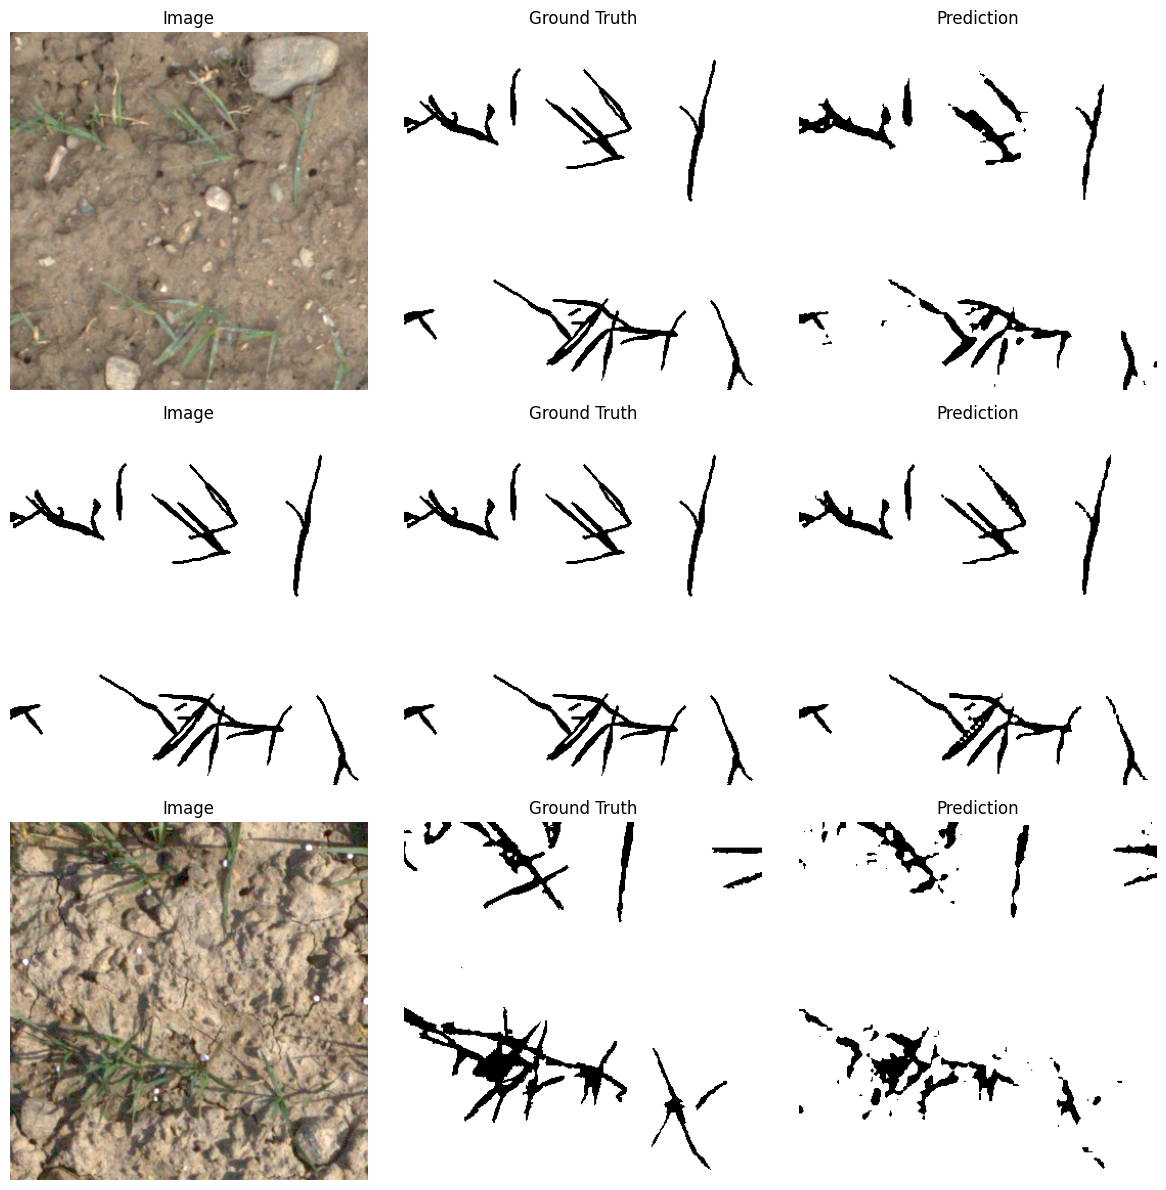

In [31]:

best_run_name = results_df.iloc[0]["run_name"]
best_run = next(x for x in stored_runs if x["run_name"] == best_run_name)

print("Best run:", best_run_name)
show_predictions(
    best_run["model"],
    best_run["processor"],
    best_run["test_set"],
    best_run["model_type"],
    num_samples=3,
)
